In [9]:
import pandas as pd

In [10]:
df = pd.read_csv("kopaScore_dataset.csv")
df.head()

,Unnamed: 0,user_id,monthly_inflow,inflow_volatility,monthly_outflow,airtime_count,prior_defaults,loan_amount,net_cashflow_ratio,loan_to_income_ratio,is_default
0,0,USR_10000,42450.712295,0.226690,29110.784453,16,0,28247.506642,1.458,0.665,0
1,1,USR_10001,32926.035482,0.106661,25465.032387,13,0,29429.696256,1.293,0.894,0
2,2,USR_10002,44715.328072,0.089494,48518.406170,9,0,17452.756607,0.922,0.390,1
3,3,USR_10003,57845.447846,0.101852,57289.780019,17,1,16327.775151,1.010,0.282,0
4,4,USR_10004,31487.699379,0.370578,23341.687219,13,1,16354.199800,1.349,0.519,0


In [11]:
numeric = df.select_dtypes(include = "number")
numeric.corr()

,Unnamed: 0,monthly_inflow,inflow_volatility,monthly_outflow,airtime_count,prior_defaults,loan_amount,net_cashflow_ratio,loan_to_income_ratio,is_default
Unnamed: 0,1.000000,-0.009672,0.024942,-0.011799,-0.000085,-0.001523,-0.014247,0.006431,0.005600,0.001723
monthly_inflow,-0.009672,1.000000,-0.002599,0.917774,-0.008949,0.006029,-0.001727,0.028193,-0.596648,-0.208240
inflow_volatility,0.024942,-0.002599,1.000000,-0.010934,0.008822,0.011633,0.000986,0.018350,-0.000732,0.211544
monthly_outflow,-0.011799,0.917774,-0.010934,1.000000,-0.006293,0.006352,-0.007438,-0.335269,-0.548608,-0.141390
airtime_count,-0.000085,-0.008949,0.008822,-0.006293,1.000000,-0.013771,-0.008496,-0.011597,0.005532,0.015134
prior_defaults,-0.001523,0.006029,0.011633,0.006352,-0.013771,1.000000,-0.023784,-0.005418,-0.018407,0.254816
loan_amount,-0.014247,-0.001727,0.000986,-0.007438,-0.008496,-0.023784,1.000000,0.009628,0.552526,0.269779
net_cashflow_ratio,0.006431,0.028193,0.018350,-0.335269,-0.011597,-0.005418,0.009628,1.000000,-0.038539,-0.139773
loan_to_income_ratio,0.005600,-0.596648,-0.000732,-0.548608,0.005532,-0.018407,0.552526,-0.038539,1.000000,0.312685
is_default,0.001723,-0.208240,0.211544,-0.141390,0.015134,0.254816,0.269779,-0.139773,0.312685,1.000000


<Axes: >

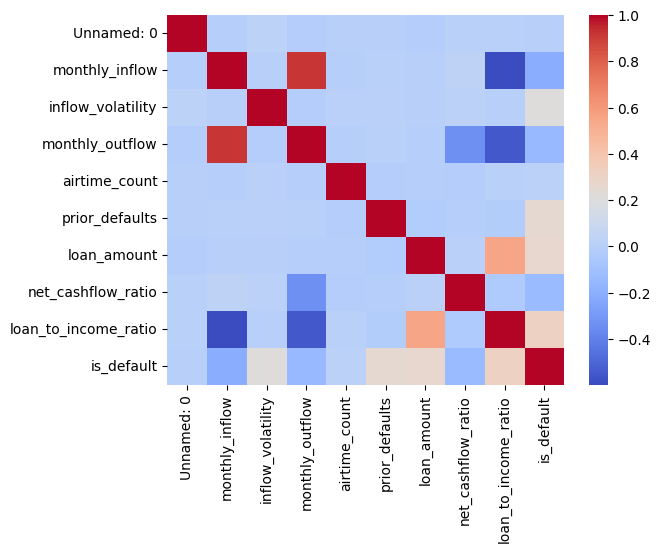

In [12]:
import seaborn as sns

sns.heatmap(
    numeric.corr(),
    cmap = "coolwarm"
)

In [13]:
!pip install ydata-profiling

In [14]:
from ydata_profiling import ProfileReport

In [15]:
report = ProfileReport(df, title = "Profiling Report for KopaScore")
report.to_file("kopaScore_profiling_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 25.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

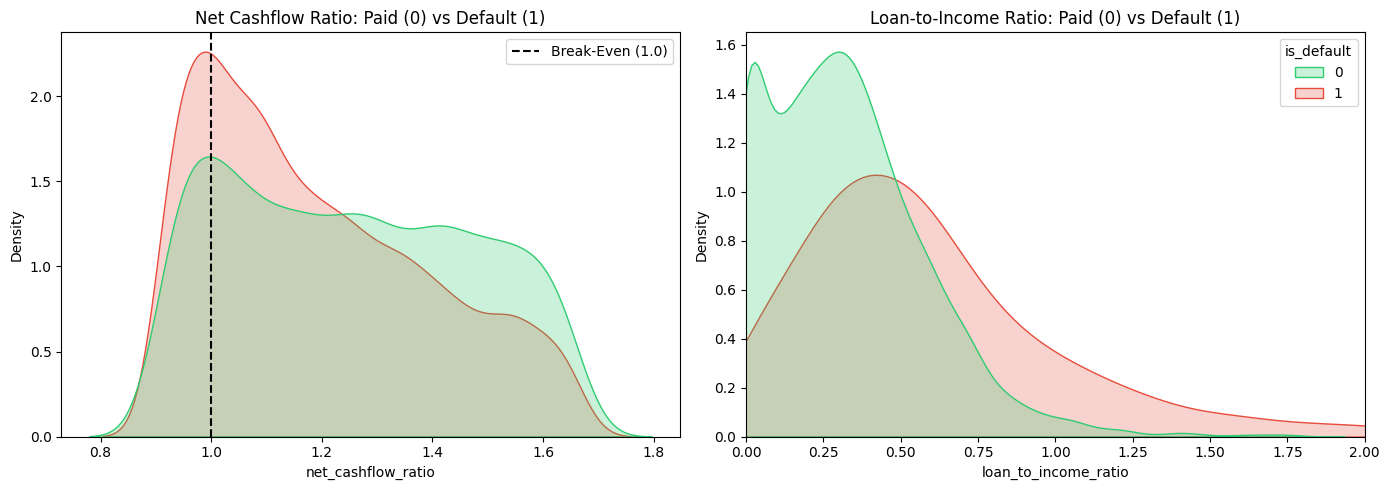

In [16]:
# Create a 1x2 subplot layout to compare key ratios
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Net Cashflow Ratio distribution split by default status
sns.kdeplot( #kernel density estimate plot --> it's like a smooth histogram
    data=df,
    x="net_cashflow_ratio",
    hue="is_default",
    common_norm=False,
    fill=True,
    palette=["#2ecc71", "#e74c3c"],
    ax=axes[0],
)
axes[0].set_title("Net Cashflow Ratio: Paid (0) vs Default (1)")
axes[0].axvline(
    1.0, color="black", linestyle="--", label="Break-Even (1.0)"
)
axes[0].legend()

# Plot 2: Loan-to-Income Ratio distribution split by default status
sns.kdeplot(
    data=df,
    x="loan_to_income_ratio",
    hue="is_default",
    common_norm=False,
    fill=True,
    palette=["#2ecc71", "#e74c3c"],
    ax=axes[1],
)
axes[1].set_title("Loan-to-Income Ratio: Paid (0) vs Default (1)")
axes[1].set_xlim(0, 2.0)  # Caps the view so 35,000 (the crazy ratios, ile wakati tulireplace the zeros with 1) doesn't squash the chart

plt.tight_layout()
plt.show()

These are 2 plots showing the behaviour of those who pay back on time (green) and those who defualt (red)

From the first plot we can see, most of the people who default are living from paycheck to paycheck (1.0), but the people who pay on time, we can see they have a ratio of more than 1.0, meaning they are saving or they are spending less money than they earn.

From the second plot, people who paid on time, took loan less than their earnings (10% - 25%), so they are able to pay because they won't struggle that much, but most people who defaulted, even if they took a lesser amount of loan, we can see that the loan was 50% - 75% of their earnings, meaning that they struggled to pay back the loan, making them default.

In [17]:
df.head()

,Unnamed: 0,user_id,monthly_inflow,inflow_volatility,monthly_outflow,airtime_count,prior_defaults,loan_amount,net_cashflow_ratio,loan_to_income_ratio,is_default
0,0,USR_10000,42450.712295,0.226690,29110.784453,16,0,28247.506642,1.458,0.665,0
1,1,USR_10001,32926.035482,0.106661,25465.032387,13,0,29429.696256,1.293,0.894,0
2,2,USR_10002,44715.328072,0.089494,48518.406170,9,0,17452.756607,0.922,0.390,1
3,3,USR_10003,57845.447846,0.101852,57289.780019,17,1,16327.775151,1.010,0.282,0
4,4,USR_10004,31487.699379,0.370578,23341.687219,13,1,16354.199800,1.349,0.519,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            10000 non-null  int64  
 1   user_id               10000 non-null  object 
 2   monthly_inflow        10000 non-null  float64
 3   inflow_volatility     10000 non-null  float64
 4   monthly_outflow       10000 non-null  float64
 5   airtime_count         10000 non-null  int64  
 6   prior_defaults        10000 non-null  int64  
 7   loan_amount           10000 non-null  float64
 8   net_cashflow_ratio    10000 non-null  float64
 9   loan_to_income_ratio  10000 non-null  float64
 10  is_default            10000 non-null  int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 859.5+ KB


I've removed the Unnamed column using df.drop()

In [23]:
df.head()

,user_id,monthly_inflow,inflow_volatility,monthly_outflow,airtime_count,prior_defaults,loan_amount,net_cashflow_ratio,loan_to_income_ratio,is_default
0,USR_10000,42450.712295,0.226690,29110.784453,16,0,28247.506642,1.458,0.665,0
1,USR_10001,32926.035482,0.106661,25465.032387,13,0,29429.696256,1.293,0.894,0
2,USR_10002,44715.328072,0.089494,48518.406170,9,0,17452.756607,0.922,0.390,1
3,USR_10003,57845.447846,0.101852,57289.780019,17,1,16327.775151,1.010,0.282,0
4,USR_10004,31487.699379,0.370578,23341.687219,13,1,16354.199800,1.349,0.519,0


In [24]:
df.to_csv("kopaScore_processed.csv")